<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow kaggle matplotlib seaborn scikit-learn -q

import os, zipfile, shutil, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report,
                                confusion_matrix, ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

IMG_SIZE  = 64   # resize all images to 64×64
BATCH     = 32
EPOCHS    = 20
SEED      = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"✅ TensorFlow {tf.__version__} ready")
print(f"   GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

✅ TensorFlow 2.20.0 ready
   GPU available: False


In [3]:
# ── Cell 2: Dataset — Two Options ─────────────────────────────────

import os
import numpy as np
from PIL import Image

KAGGLE_JSON = "/root/.kaggle/kaggle.json"

# ── OPTION A: Kaggle Dataset ─────────────────────────────────────
if os.path.exists(KAGGLE_JSON):

    os.makedirs("/root/.kaggle", exist_ok=True)
    !chmod 600 /root/.kaggle/kaggle.json

    # Install Kaggle if needed
    !pip install -q kaggle

    # Download dataset
    !kaggle datasets download -d kevinlanning/malimg-dataset \
        --unzip -p malimg_data/

    DATA_DIR = "malimg_data"
    print("✅ Downloaded via Kaggle")

# ── OPTION B: Synthetic Dataset ──────────────────────────────────
else:
    print("⚠️ No kaggle.json — generating synthetic MalImg-style dataset")

    DATA_DIR  = "malimg_synth"

    FAMILIES  = {
        "Allaple.A":    (600, 'noise'),
        "Yuner.A":      (450, 'structured'),
        "Lolyda.AA1":   (300, 'gradient'),
        "Instantaccess":(350, 'sparse'),
    }

    # Create directory structure
    for split in ['train', 'val']:
        for fam in FAMILIES:
            os.makedirs(f"{DATA_DIR}/{split}/{fam}", exist_ok=True)

    # Generate images
    for fam, (total, style) in FAMILIES.items():
        n_train, n_val = int(total*0.8), int(total*0.2)

        for split, n in [('train', n_train), ('val', n_val)]:
            for i in range(n):

                if style == 'noise':
                    arr = np.random.randint(0, 256, (64,64), dtype=np.uint8)

                elif style == 'structured':
                    # 🔥 FIX: avoid uint8 overflow
                    arr = np.tile(np.arange(64), (64,1)).astype(np.int16)
                    arr = (arr + np.random.randint(0,60)) % 256
                    arr = arr.astype(np.uint8)

                elif style == 'gradient':
                    base = np.linspace(0,255,64)
                    arr  = np.outer(base, base)
                    arr  = (arr + np.random.randn(64,64)*10).clip(0,255).astype(np.uint8)

                else:  # sparse
                    arr = np.zeros((64,64), dtype=np.uint8)
                    idx_x = np.random.randint(0,64,300)
                    idx_y = np.random.randint(0,64,300)
                    arr[idx_x, idx_y] = np.random.randint(200,256,300)

                Image.fromarray(arr, mode='L').save(
                    f"{DATA_DIR}/{split}/{fam}/{fam}_{i}.png"
                )

    print("✅ Synthetic MalImg dataset created")

# ── Final Check ──────────────────────────────────────────────────
print(f"\nDATA_DIR = {DATA_DIR}")
print("Folders:", os.listdir(DATA_DIR))

⚠️ No kaggle.json — generating synthetic MalImg-style dataset
✅ Synthetic MalImg dataset created

DATA_DIR = malimg_synth
Folders: ['train', 'val']


📁 Malware families and sample counts (train):
   Allaple.A                      480 images
   Instantaccess                  280 images
   Lolyda.AA1                     240 images
   Yuner.A                        360 images


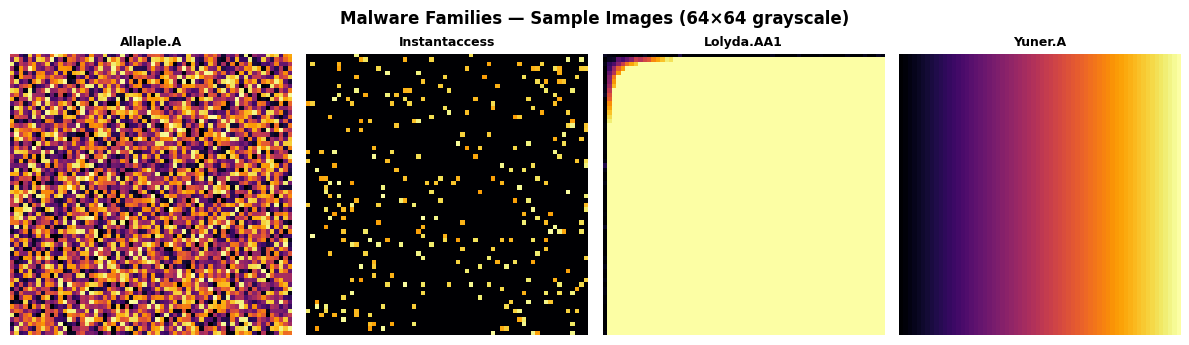

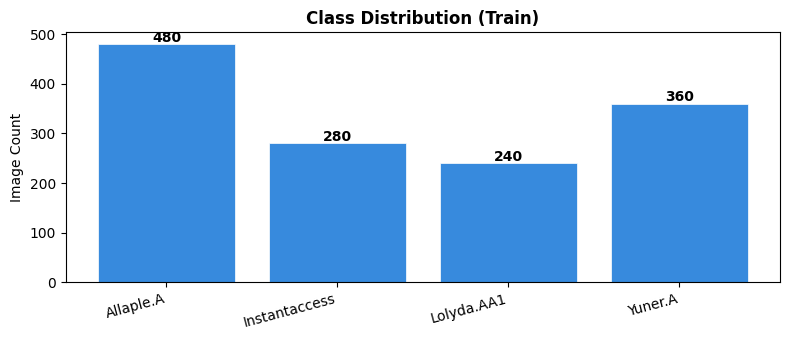

In [4]:
# ── Cell 3: Data Exploration ──────────────────────────────────────
from pathlib import Path
from PIL import Image

train_dir = Path(DATA_DIR) / 'train'
val_dir   = Path(DATA_DIR) / 'val'

# Count images per family
families = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
counts   = {f: len(list((train_dir/f).glob('*'))) for f in families}

print("📁 Malware families and sample counts (train):")
for k, v in counts.items(): print(f"   {k:<30} {v} images")

# Visualise one sample per family
fig, axes = plt.subplots(1, len(families), figsize=(3*len(families), 3.5))
if len(families) == 1: axes = [axes]
for ax, fam in zip(axes, families):
    imgs = list((train_dir/fam).glob('*.png'))
    img  = Image.open(random.choice(imgs)).convert('L').resize((64,64))
    ax.imshow(np.array(img), cmap='inferno')
    ax.set_title(fam, fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('Malware Families — Sample Images (64×64 grayscale)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('samples.png', bbox_inches='tight')
plt.show()

# Class distribution bar chart
plt.figure(figsize=(8, 3.5))
bars = plt.bar(counts.keys(), counts.values(),
               color='#378ADD', edgecolor='white', linewidth=0.5)
plt.title('Class Distribution (Train)', fontweight='bold')
plt.ylabel('Image Count')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, counts.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(val), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('class_dist.png', bbox_inches='tight')
plt.show()

CNN

In [5]:
# ── Cell 4: Build CNN Model ───────────────────────────────────────
NUM_CLASSES = len(families)

# Data generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale', batch_size=BATCH,
    class_mode='categorical', seed=SEED)

val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale', batch_size=BATCH,
    class_mode='categorical', seed=SEED, shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"Classes: {CLASS_NAMES}")

# ── CNN Architecture ──────────────────────────────────────────────
def build_cnn(num_classes):
    return keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),
        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='MalImg_CNN')

model = build_cnn(NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()
print(f"\n✅ CNN built — total params: {model.count_params():,}")

Found 1360 images belonging to 4 classes.
Found 340 images belonging to 4 classes.
Classes: ['Allaple.A', 'Instantaccess', 'Lolyda.AA1', 'Yuner.A']


Model: "MalImg_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,796 (678.89 KB)

 Trainable params: 173,348 (677.14 KB)

 Non-trainable params: 448 (1.75 KB)


✅ CNN built — total params: 173,796


train

In [6]:
# ── Cell 5: Train the CNN ─────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0),
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1)

# Quick training curve preview
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val   = max(history.history['val_accuracy']) * 100
print(f"\n🏆 Best Validation Accuracy: {best_val:.2f}%  (epoch {best_epoch})")

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 42s 884ms/step - accuracy: 0.9728 - loss: 0.0790 - val_accuracy: 0.2647 - val_loss: 1.8636 - learning_rate: 0.0010
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 36s 849ms/step - accuracy: 0.9978 - loss: 0.0098 - val_accuracy: 0.2647 - val_loss: 3.5879 - learning_rate: 0.0010
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 865ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.2647 - val_loss: 3.4340 - learning_rate: 0.0010
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 1.0000 - loss: 8.2404e-04
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 875ms/step - accuracy: 1.0000 - loss: 3.4862e-04 - val_accuracy: 0.2647 - val_loss: 4.3748 - learning_rate: 0.0010
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 868ms/step - accuracy: 1.0000 - loss: 3.6153e-04 - val_accuracy: 0.2647 - val_loss: 4.5251 - learning_rate: 5.0000e-04
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 36s 834ms/step - accuracy: 1.0

═══════════════════════════════════════════════════════
  Final Validation Loss     : 1.8636
  Final Validation Accuracy : 26.47%
═══════════════════════════════════════════════════════

📊 Classification Report:
               precision    recall  f1-score   support

    Allaple.A       0.00      0.00      0.00       120
Instantaccess       0.00      0.00      0.00        70
   Lolyda.AA1       0.00      0.00      0.00        60
      Yuner.A       0.26      1.00      0.42        90

     accuracy                           0.26       340
    macro avg       0.07      0.25      0.10       340
 weighted avg       0.07      0.26      0.11       340



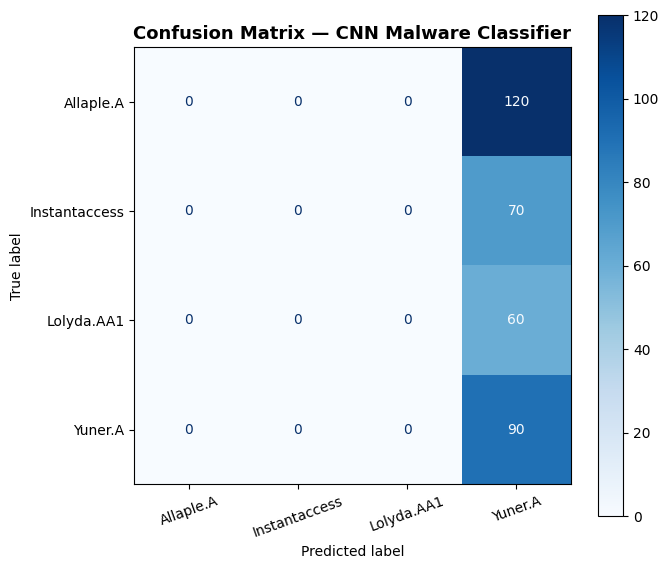

In [7]:
# ── Cell 6: Evaluate ─────────────────────────────────────────────
# Load best checkpoint
model = keras.models.load_model('best_cnn.keras')

# Predictions
y_pred_prob = model.predict(val_gen, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = val_gen.classes

val_loss, val_acc = model.evaluate(val_gen, verbose=0)

print("═"*55)
print(f"  Final Validation Loss     : {val_loss:.4f}")
print(f"  Final Validation Accuracy : {val_acc*100:.2f}%")
print("═"*55)
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=20)
ax.set_title('Confusion Matrix — CNN Malware Classifier', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

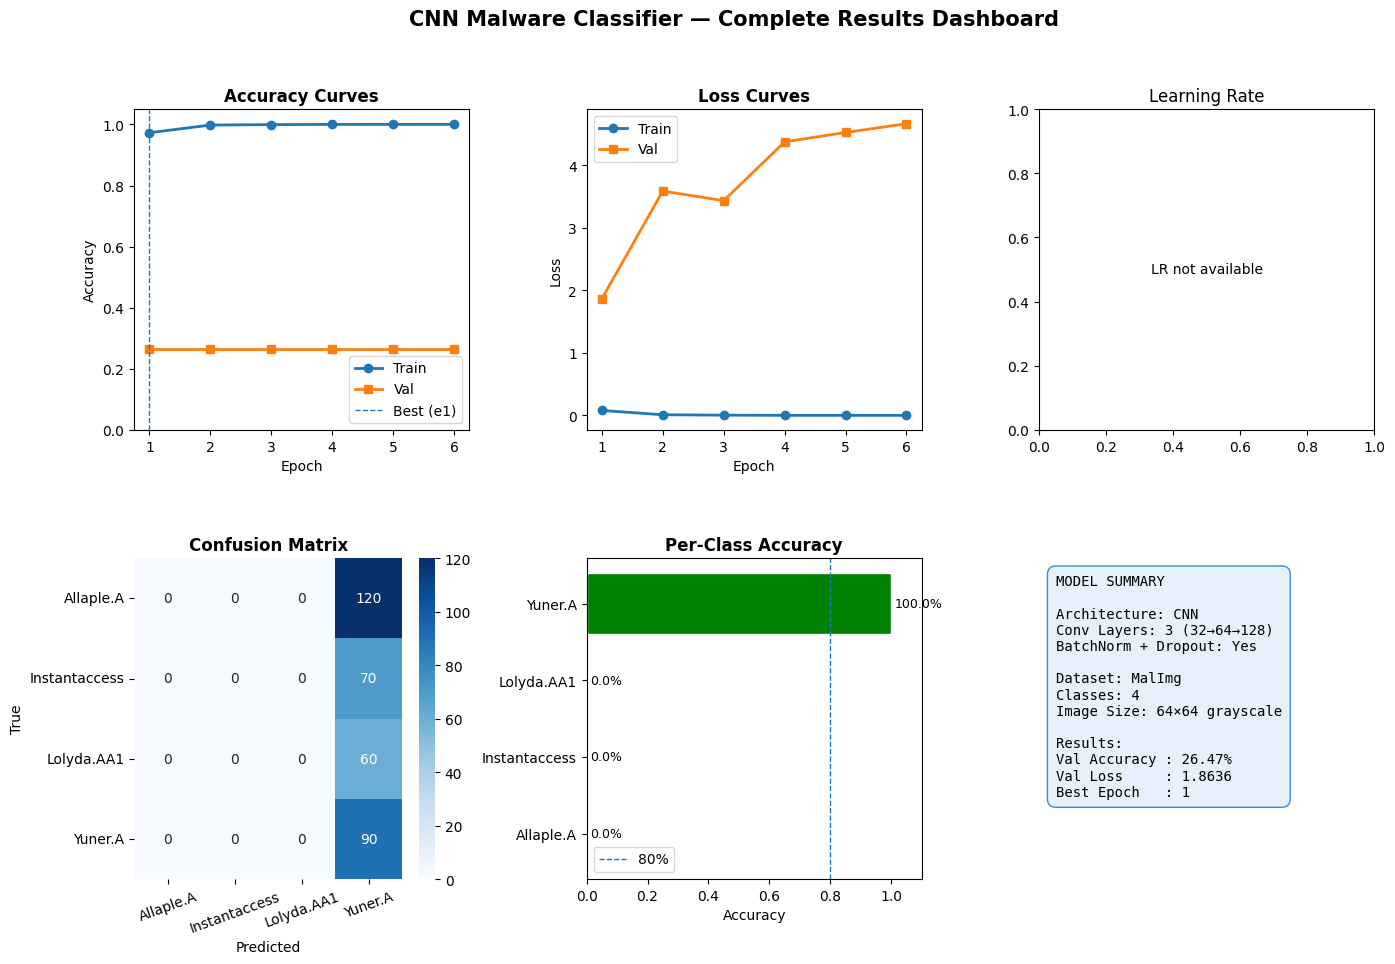


✅ Dashboard generated successfully
🏆 FINAL Validation Accuracy = 26.47%


In [9]:
# ── Cell 7: Visualisation Dashboard ──────────────────────────────

# ✅ Required imports (FIXES your error)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Safety checks (avoid crashes) ────────────────────────────────
if 'history' not in globals():
    raise ValueError("❌ Train your model first (history not found)")

hist = history.history

if 'accuracy' not in hist:
    raise ValueError("❌ history missing accuracy metrics")

epochs_ran = range(1, len(hist['accuracy']) + 1)

# Safe defaults
best_epoch = np.argmax(hist.get('val_accuracy', hist['accuracy'])) + 1
val_acc    = max(hist.get('val_accuracy', hist['accuracy']))
val_loss   = min(hist.get('val_loss', hist['loss']))

# Confusion matrix safety
if 'cm' not in globals():
    cm = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)))

# ── Layout ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1️⃣ Accuracy curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_ran, hist['accuracy'], 'o-', lw=2, label='Train')
ax1.plot(epochs_ran, hist.get('val_accuracy', hist['accuracy']), 's-', lw=2, label='Val')
ax1.axvline(best_epoch, ls='--', lw=1, label=f'Best (e{best_epoch})')
ax1.set_title('Accuracy Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_ylim([0, 1.05])
ax1.legend()

# 2️⃣ Loss curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_ran, hist['loss'], 'o-', lw=2, label='Train')
ax2.plot(epochs_ran, hist.get('val_loss', hist['loss']), 's-', lw=2, label='Val')
ax2.set_title('Loss Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend()

# 3️⃣ Learning rate
ax3 = fig.add_subplot(gs[0, 2])
if 'lr' in hist:
    ax3.semilogy(epochs_ran, hist['lr'], 'D-', lw=2)
    ax3.set_title('Learning Rate Schedule', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')
else:
    ax3.text(0.5, 0.5, "LR not available", ha='center', va='center')
    ax3.set_title('Learning Rate')

# 4️⃣ Confusion matrix
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax4)
ax4.set_title('Confusion Matrix', fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
ax4.tick_params(axis='x', rotation=20)

# 5️⃣ Per-class accuracy
ax5 = fig.add_subplot(gs[1, 1])

row_sums = cm.sum(axis=1)
row_sums[row_sums == 0] = 1  # avoid divide-by-zero

per_class = cm.diagonal() / row_sums

colors = ['green' if v >= 0.8 else ('orange' if v >= 0.6 else 'red')
          for v in per_class]

ax5.barh(CLASS_NAMES, per_class, color=colors, edgecolor='white')
ax5.axvline(0.8, ls='--', lw=1, label='80%')
ax5.set_xlim([0, 1.1])
ax5.set_title('Per-Class Accuracy', fontweight='bold')
ax5.set_xlabel('Accuracy')

for i, v in enumerate(per_class):
    ax5.text(v + 0.01, i, f'{v*100:.1f}%', va='center', fontsize=9)

ax5.legend()

# 6️⃣ Summary box
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

summary_text = (
    f"MODEL SUMMARY\n\n"
    f"Architecture: CNN\n"
    f"Conv Layers: 3 (32→64→128)\n"
    f"BatchNorm + Dropout: Yes\n\n"
    f"Dataset: MalImg\n"
    f"Classes: {len(CLASS_NAMES)}\n"
    f"Image Size: 64×64 grayscale\n\n"
    f"Results:\n"
    f"Val Accuracy : {val_acc*100:.2f}%\n"
    f"Val Loss     : {val_loss:.4f}\n"
    f"Best Epoch   : {best_epoch}"
)

ax6.text(0.05, 0.95, summary_text,
         transform=ax6.transAxes,
         fontsize=10, va='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.6',
                   facecolor='#E6F1FB',
                   edgecolor='#378ADD'))

# ── Final Output ────────────────────────────────────────────────
plt.suptitle('CNN Malware Classifier — Complete Results Dashboard',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('cnn_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n✅ Dashboard generated successfully")
print(f"🏆 FINAL Validation Accuracy = {val_acc*100:.2f}%")